0단계

▶ [Stage 0] 리뷰 0개 (완전 침묵) 게임 태그 분석 준비 중...


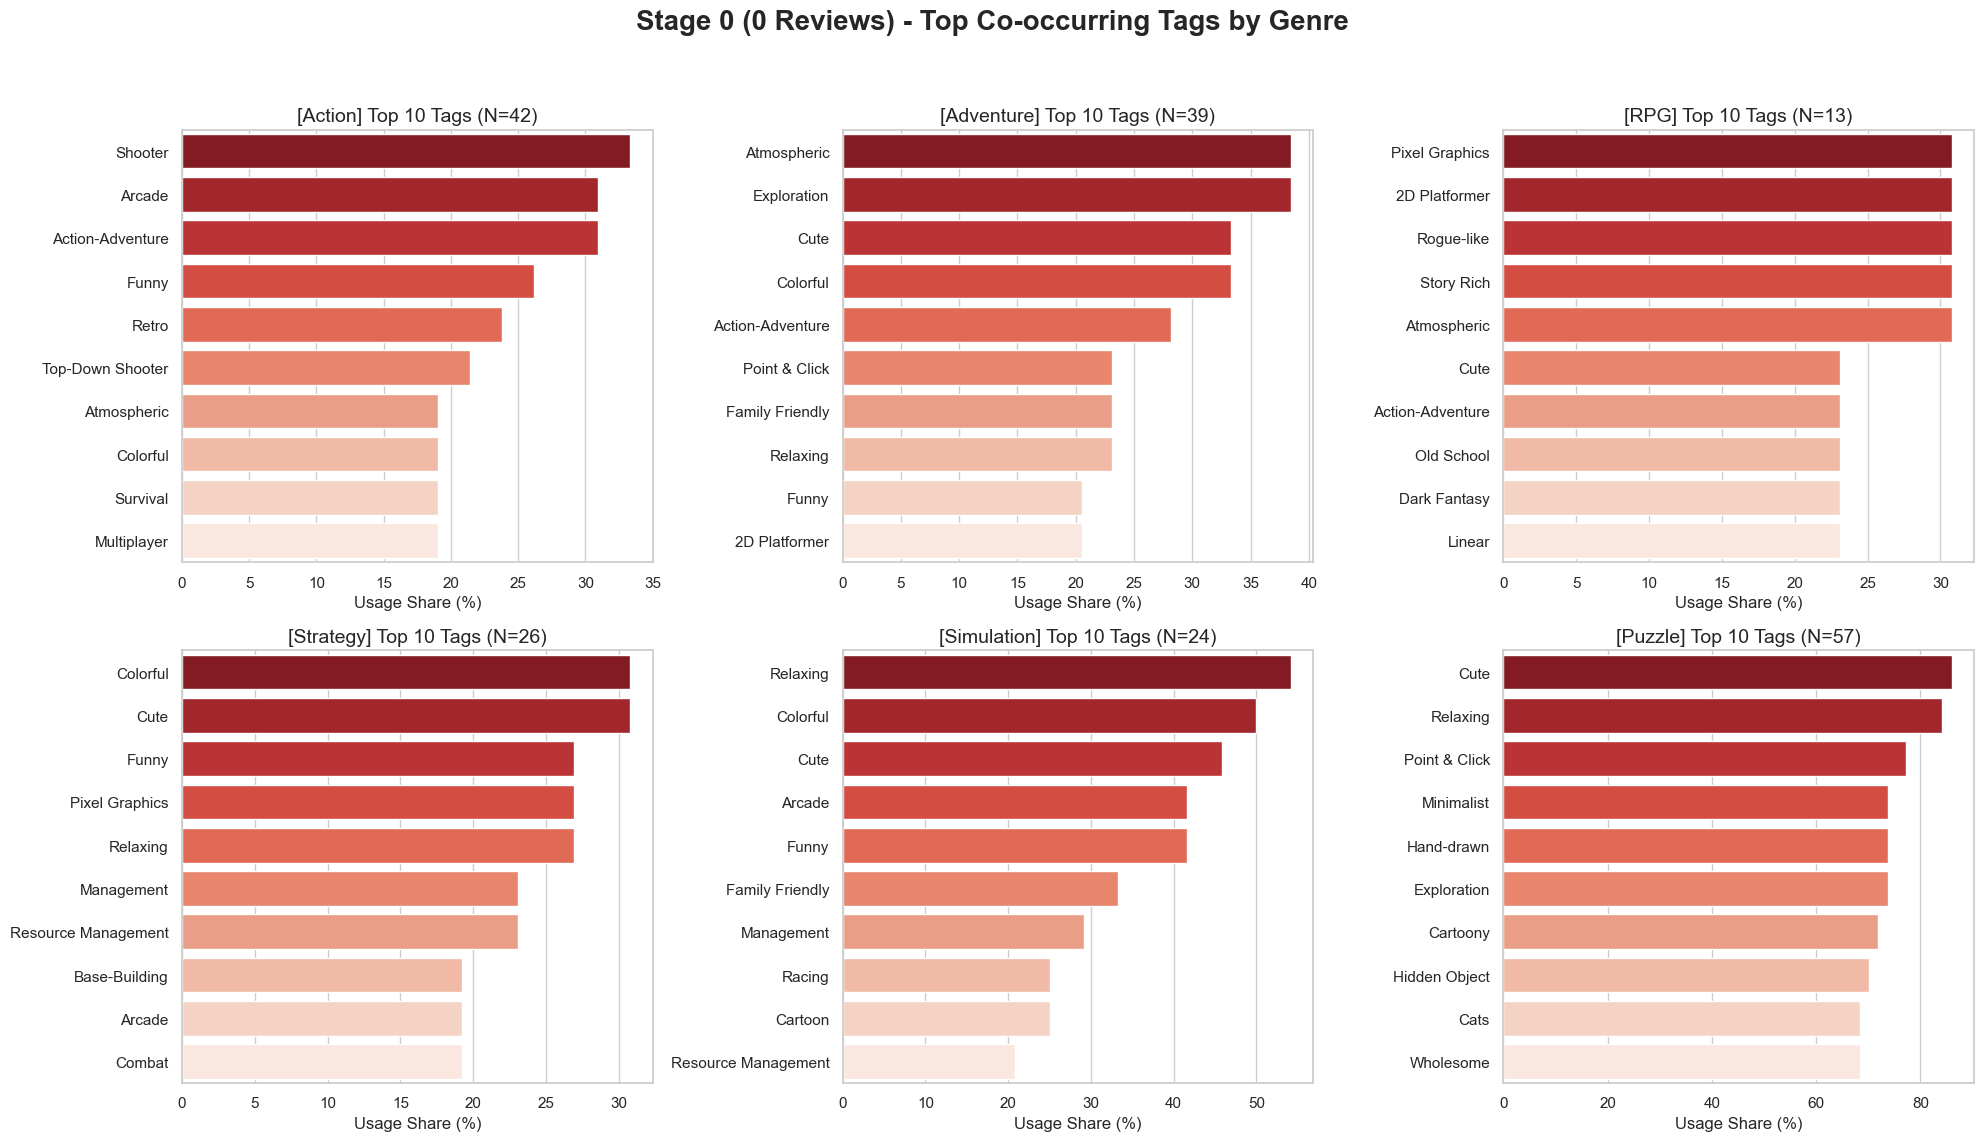


💡 [Stage 0] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Shooter,Atmospheric,Pixel Graphics,Colorful,Relaxing,Cute
Top 2,Arcade,Exploration,2D Platformer,Cute,Colorful,Relaxing
Top 3,Action-Adventure,Cute,Rogue-like,Funny,Cute,Point & Click
Top 4,Funny,Colorful,Story Rich,Pixel Graphics,Arcade,Minimalist
Top 5,Retro,Action-Adventure,Atmospheric,Relaxing,Funny,Hand-drawn
Top 6,Top-Down Shooter,Point & Click,Cute,Management,Family Friendly,Exploration
Top 7,Atmospheric,Family Friendly,Action-Adventure,Resource Management,Management,Cartoony
Top 8,Colorful,Relaxing,Old School,Base-Building,Racing,Hidden Object
Top 9,Survival,Funny,Dark Fantasy,Arcade,Cartoon,Cats
Top 10,Multiplayer,2D Platformer,Linear,Combat,Resource Management,Wholesome


In [15]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 0] 리뷰 0개 (완전 침묵) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 0 필터링 (리뷰 0개)
df_target = df_all[df_all['total_reviews'] == 0].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 0 (0 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Reds_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 0] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

1단계

▶ [Stage 1] 리뷰 1~9개 (정체 구간) 게임 태그 분석 준비 중...


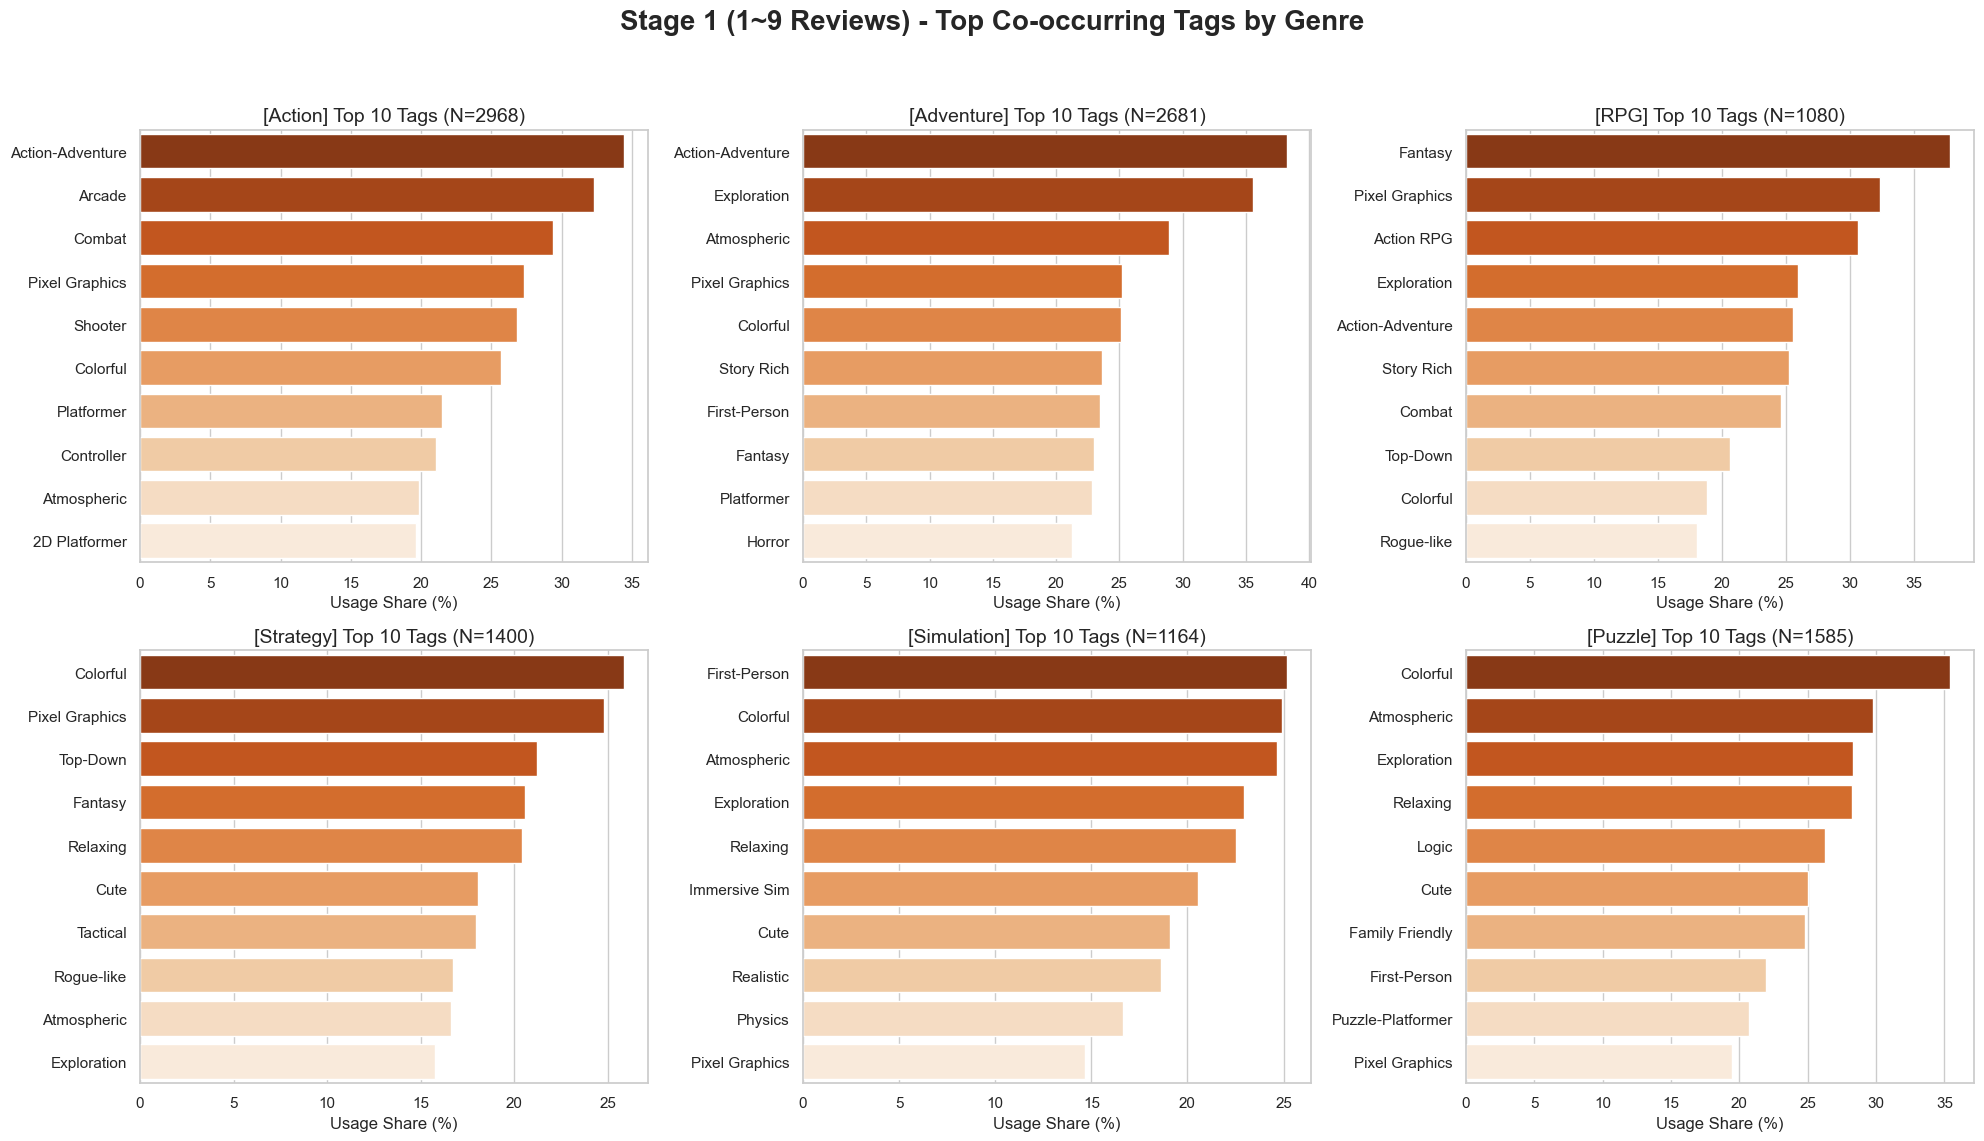


💡 [Stage 1] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Action-Adventure,Fantasy,Colorful,First-Person,Colorful
Top 2,Arcade,Exploration,Pixel Graphics,Pixel Graphics,Colorful,Atmospheric
Top 3,Combat,Atmospheric,Action RPG,Top-Down,Atmospheric,Exploration
Top 4,Pixel Graphics,Pixel Graphics,Exploration,Fantasy,Exploration,Relaxing
Top 5,Shooter,Colorful,Action-Adventure,Relaxing,Relaxing,Logic
Top 6,Colorful,Story Rich,Story Rich,Cute,Immersive Sim,Cute
Top 7,Platformer,First-Person,Combat,Tactical,Cute,Family Friendly
Top 8,Controller,Fantasy,Top-Down,Rogue-like,Realistic,First-Person
Top 9,Atmospheric,Platformer,Colorful,Atmospheric,Physics,Puzzle-Platformer
Top 10,2D Platformer,Horror,Rogue-like,Exploration,Pixel Graphics,Pixel Graphics


In [16]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 1] 리뷰 1~9개 (정체 구간) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 1 필터링 (리뷰 1~9개)
df_target = df_all[(df_all['total_reviews'] >= 1) & (df_all['total_reviews'] <= 9)].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 1 (1~9 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Oranges_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 1] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

▶ [Stage 2] 리뷰 10~49개 (초기 도약) 게임 태그 분석 준비 중...


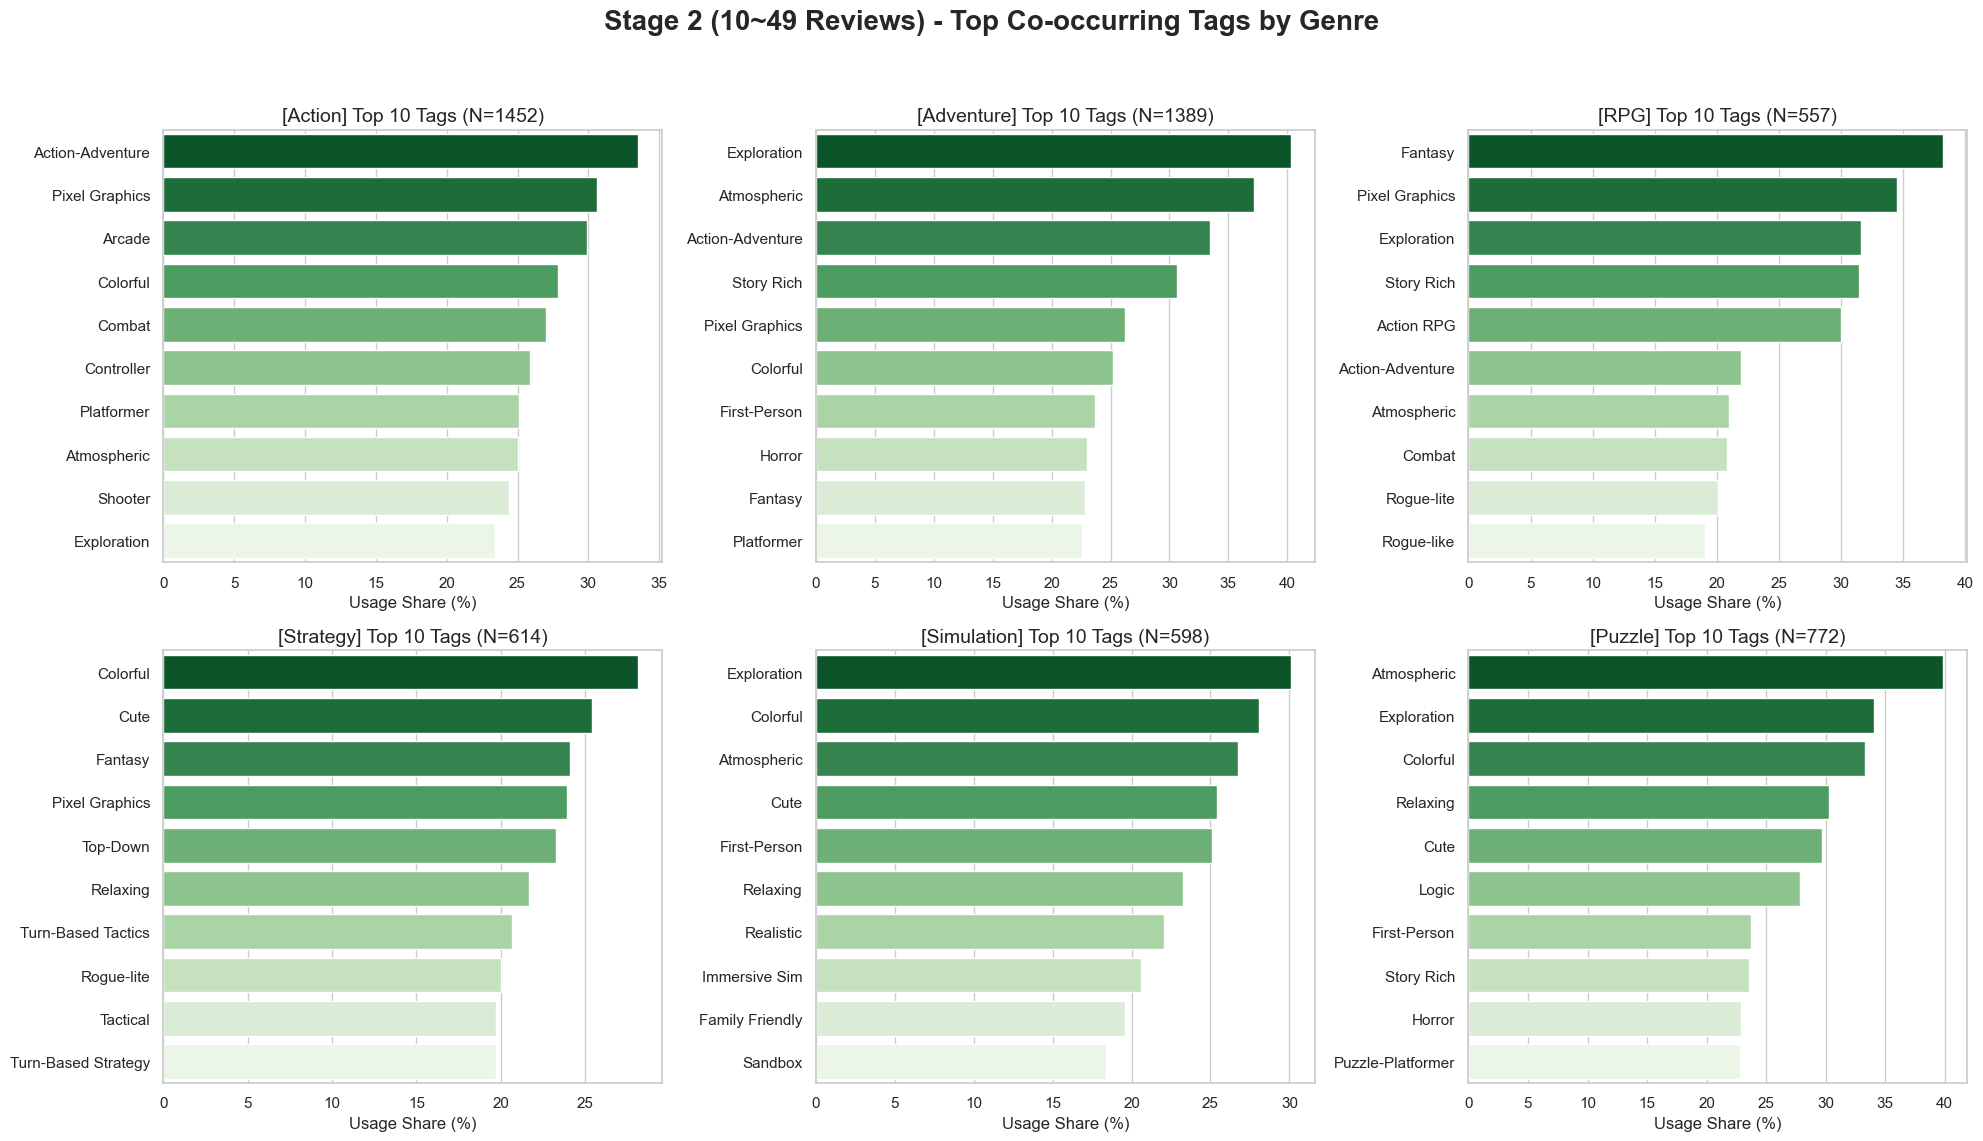


💡 [Stage 2] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Exploration,Fantasy,Colorful,Exploration,Atmospheric
Top 2,Pixel Graphics,Atmospheric,Pixel Graphics,Cute,Colorful,Exploration
Top 3,Arcade,Action-Adventure,Exploration,Fantasy,Atmospheric,Colorful
Top 4,Colorful,Story Rich,Story Rich,Pixel Graphics,Cute,Relaxing
Top 5,Combat,Pixel Graphics,Action RPG,Top-Down,First-Person,Cute
Top 6,Controller,Colorful,Action-Adventure,Relaxing,Relaxing,Logic
Top 7,Platformer,First-Person,Atmospheric,Turn-Based Tactics,Realistic,First-Person
Top 8,Atmospheric,Horror,Combat,Rogue-lite,Immersive Sim,Story Rich
Top 9,Shooter,Fantasy,Rogue-lite,Tactical,Family Friendly,Horror
Top 10,Exploration,Platformer,Rogue-like,Turn-Based Strategy,Sandbox,Puzzle-Platformer


In [17]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 2] 리뷰 10~49개 (초기 도약) 게임 태그 분석 준비 중...")
print("="*60)

# 1. 데이터 로드
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 2. Stage 2 필터링 (리뷰 10~49개)
df_target = df_all[(df_all['total_reviews'] >= 10) & (df_all['total_reviews'] <= 49)].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 2 (10~49 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Greens_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n💡 [Stage 2] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

0+1단계

▶ [Stage 0+1] 리뷰 0~9개 (초기 정체 구간 통합) 게임 태그 분석 준비 중...


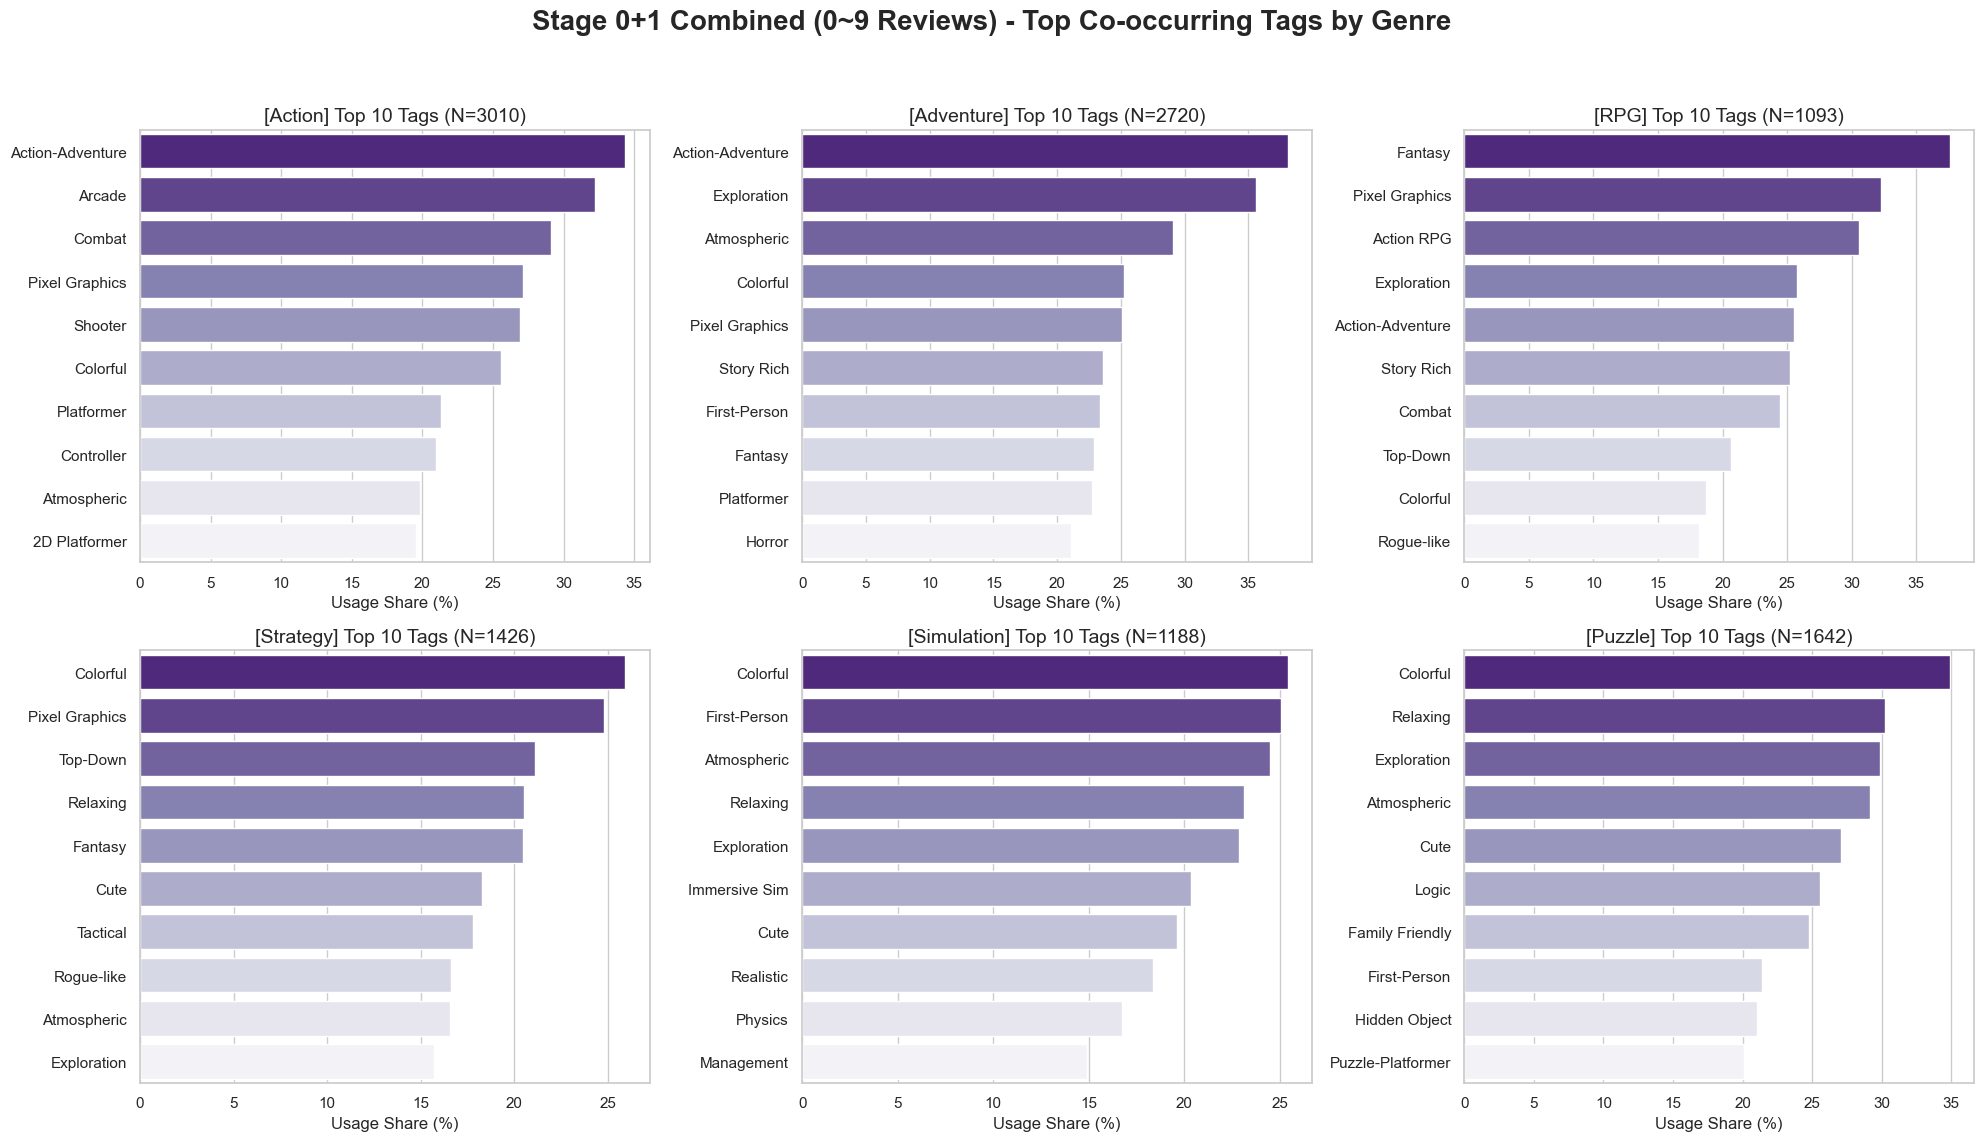


💡 [Stage 0+1 통합] 장르별 핵심 동반 태그 TOP 10 요약


,Action,Adventure,RPG,Strategy,Simulation,Puzzle
Top 1,Action-Adventure,Action-Adventure,Fantasy,Colorful,Colorful,Colorful
Top 2,Arcade,Exploration,Pixel Graphics,Pixel Graphics,First-Person,Relaxing
Top 3,Combat,Atmospheric,Action RPG,Top-Down,Atmospheric,Exploration
Top 4,Pixel Graphics,Colorful,Exploration,Relaxing,Relaxing,Atmospheric
Top 5,Shooter,Pixel Graphics,Action-Adventure,Fantasy,Exploration,Cute
Top 6,Colorful,Story Rich,Story Rich,Cute,Immersive Sim,Logic
Top 7,Platformer,First-Person,Combat,Tactical,Cute,Family Friendly
Top 8,Controller,Fantasy,Top-Down,Rogue-like,Realistic,First-Person
Top 9,Atmospheric,Platformer,Colorful,Atmospheric,Physics,Hidden Object
Top 10,2D Platformer,Horror,Rogue-like,Exploration,Management,Puzzle-Platformer


In [18]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# 1. 시각화 기본 설정
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("="*60)
print("▶ [Stage 0+1] 리뷰 0~9개 (초기 정체 구간 통합) 게임 태그 분석 준비 중...")
print("="*60)

# 2. 데이터 로드 및 전처리
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv'
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# 🚨 0단계와 1단계 통합 필터링 (리뷰 0개 이상 9개 이하)
df_target = df_all[df_all['total_reviews'] <= 9].copy()

# 3. 태그 추출 함수
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_target['tag_list'] = df_target['tags'].apply(extract_tags)

# 4. 분석 설정
target_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Puzzle']
# 공통/범용 태그 제외 (특징적인 태그만 추출하기 위함)
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Casual', 'Early Access'] + target_genres

genre_top_tags = {}

# 2x3 시각화 그리드 설정
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle("Stage 0+1 Combined (0~9 Reviews) - Top Co-occurring Tags by Genre", fontsize=20, fontweight='bold')

for i, genre in enumerate(target_genres):
    # 해당 장르 태그를 보유한 게임 필터링
    genre_df = df_target[df_target['tag_list'].apply(lambda x: genre in x)]
    total_genre_games = len(genre_df)
    
    if total_genre_games == 0:
        continue
        
    # 해당 장르 게임들이 가진 '다른' 특징적 태그 수집
    all_tags_in_genre = []
    for tags in genre_df['tag_list']:
        filtered_tags = [t for t in tags if t not in common_tags]
        all_tags_in_genre.extend(filtered_tags)
        
    # 태그 빈도 계산 및 비율(%) 변환
    tag_counts = Counter(all_tags_in_genre)
    top10_tags = pd.Series({tag: (count / total_genre_games) * 100 for tag, count in tag_counts.items()}).sort_values(ascending=False).head(10)
    genre_top_tags[genre] = top10_tags
    
    # 시각화 (가로 막대 그래프)
    plot_df = top10_tags.reset_index()
    plot_df.columns = ['Tag', 'Share(%)']
    
    # 이전 단계들과 구분되도록 보라색 계열(Purples_r) 사용
    sns.barplot(data=plot_df, x='Share(%)', y='Tag', ax=axes[i], palette='Purples_r')
    axes[i].set_title(f"[{genre}] Top 10 Tags (N={total_genre_games})", fontsize=14)
    axes[i].set_xlabel("Usage Share (%)")
    axes[i].set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. 결과 표 출력
print("\n💡 [Stage 0+1 통합] 장르별 핵심 동반 태그 TOP 10 요약")
summary_df = pd.DataFrame({genre: tags.index.tolist() for genre, tags in genre_top_tags.items()})
summary_df.index = [f"Top {i+1}" for i in range(10)]
display(summary_df)

In [19]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
from IPython.display import display
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# [1단계] 데이터 로드 및 병합
# ==========================================
print("데이터를 불러오고 분석을 준비하는 중...\n")

path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)

df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)
df_all.drop_duplicates(subset=['appid'], inplace=True)

# ==========================================
# [2단계] 리뷰 마일스톤 기준 데이터 분할
# ==========================================
def get_review_group(reviews):
    if reviews == 0:
        return 'G0_침묵 (0개)'
    elif 1 <= reviews <= 9:
        return 'G1_시동 (1~9개)'
    elif 10 <= reviews <= 49:
        return 'G2_생존 (10~49개)'
    elif 50 <= reviews <= 499:
        return 'G3_도약 (50~499개)'
    else:
        return 'G4_안착 (500개 이상)'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)

# 태그 파싱 (문자열 -> 리스트)
def extract_tags(tag_str):
    try:
        if pd.isna(tag_str): return []
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_all['tag_list'] = df_all['tags'].apply(extract_tags)

# ==========================================
# [3단계] G1 vs G2 태그 점유율 비교 및 통계 검정
# ==========================================
target_groups = ['G1_시동 (1~9개)', 'G2_생존 (10~49개)']
group_stats = {}

for group in target_groups:
    group_df = df_all[df_all['review_group'] == group]
    total_games = len(group_df)
    
    if total_games == 0: continue
        
    all_tags = []
    for tags in group_df['tag_list']:
        all_tags.extend(tags)
        
    tag_counts = Counter(all_tags)
    # 그룹 내 태그 사용 비율(%)
    tag_rates = {tag: (count / total_games) * 100 for tag, count in tag_counts.items()}
    group_stats[group] = pd.Series(tag_rates)

compare_df = pd.DataFrame(group_stats).fillna(0)

# 분석에 방해되는 너무 뻔한 공통 태그 제외
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Action', 'Adventure', 'Casual', 'Simulation']
compare_filtered = compare_df.drop(index=[t for t in common_tags if t in compare_df.index], errors='ignore')

# ---------------------------------------------------------
# 통계 검정 및 효과 크기 계산 헬퍼 함수 (G1 vs G2 전용)
# ---------------------------------------------------------
df_g1 = df_all[df_all['review_group'] == 'G1_시동 (1~9개)']
df_g2 = df_all[df_all['review_group'] == 'G2_생존 (10~49개)']

def get_tag_stats(tag):
    c_g1 = sum(df_g1['tag_list'].apply(lambda x: tag in x))
    c_g2 = sum(df_g2['tag_list'].apply(lambda x: tag in x))
    n_g1 = len(df_g1)
    n_g2 = len(df_g2)
    
    # 2x2 교차표
    table = [[c_g1, n_g1 - c_g1], [c_g2, n_g2 - c_g2]]
    chi2, p, _, _ = chi2_contingency(table)
    
    # 효과 크기 (Cramér's V)
    v = np.sqrt(chi2 / (n_g1 + n_g2))
    
    # P-value 깔끔한 출력
    p_str = "< 0.001" if p < 0.001 else f"{p:.4f}"
    
    return pd.Series([p_str, round(v, 3)], index=['P-value', "Cramér's V"])

# ==========================================
# [4단계] 최종 디스플레이 (성장 동력 & 함정 태그)
# ==========================================
if 'G1_시동 (1~9개)' in compare_filtered.columns and 'G2_생존 (10~49개)' in compare_filtered.columns:
    # G1에서 G2로 넘어갈 때의 태그 비중 증감폭
    compare_filtered['성장폭 (%p)'] = compare_filtered['G2_생존 (10~49개)'] - compare_filtered['G1_시동 (1~9개)']
    
    print("💡 [1단계 탈출 동력 태그] G1에는 적으나 G2로 갈수록 폭증하는 태그 (G2 최소 10% 이상 점유)")
    rising_top10 = compare_filtered[compare_filtered['G2_생존 (10~49개)'] >= 10].sort_values(by='성장폭 (%p)', ascending=False)[['G1_시동 (1~9개)', 'G2_생존 (10~49개)', '성장폭 (%p)']].head(10)
    
    stats_rising = rising_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([rising_top10.round(1), stats_rising], axis=1))

    print("\n💀 [1단계 정체(함정) 태그] G1에 유독 많으며 G2 진입에 방해가 되는 태그")
    # G1에서 최소 5% 이상 쓰인 태그 중 G2에서 점유율이 가장 많이 깎인 태그
    trap_top10 = compare_filtered[compare_filtered['G1_시동 (1~9개)'] >= 5].sort_values(by='성장폭 (%p)', ascending=True)[['G1_시동 (1~9개)', 'G2_생존 (10~49개)', '성장폭 (%p)']].head(10)
    
    stats_trap = trap_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([trap_top10.round(1), stats_trap], axis=1))

데이터를 불러오고 분석을 준비하는 중...

💡 [1단계 탈출 동력 태그] G1에는 적으나 G2로 갈수록 폭증하는 태그 (G2 최소 10% 이상 점유)


,G1_시동 (1~9개),G2_생존 (10~49개),성장폭 (%p),P-value,Cramér's V
Story Rich,14.8,12.9,-1.9,0.0046,0.027
Stylized,13.8,10.6,-3.2,< 0.001,0.048
Controller,15.4,11.2,-4.2,< 0.001,0.060
Exploration,20.8,16.1,-4.7,< 0.001,0.060
Atmospheric,22.0,17.2,-4.8,< 0.001,0.059
Platformer,14.9,10.0,-4.8,< 0.001,0.071
RPG,16.5,11.5,-5.0,< 0.001,0.070
Cute,19.9,14.9,-5.0,< 0.001,0.065
Relaxing,16.1,10.2,-5.9,< 0.001,0.085
First-Person,17.6,11.5,-6.0,< 0.001,0.083



💀 [1단계 정체(함정) 태그] G1에 유독 많으며 G2 진입에 방해가 되는 태그


,G1_시동 (1~9개),G2_생존 (10~49개),성장폭 (%p),P-value,Cramér's V
Arcade,21.8,11.5,-10.2,< 0.001,0.133
Colorful,27.2,18.0,-9.1,< 0.001,0.107
Pixel Graphics,24.7,15.8,-8.8,< 0.001,0.107
Strategy,21.4,12.7,-8.7,< 0.001,0.113
Puzzle,24.2,16.0,-8.3,< 0.001,0.101
Action-Adventure,20.6,12.5,-8.1,< 0.001,0.106
Combat,16.9,9.9,-7.0,< 0.001,0.100
PvE,12.5,5.7,-6.7,< 0.001,0.113
Fantasy,18.9,12.5,-6.4,< 0.001,0.086
Top-Down,15.5,9.4,-6.1,< 0.001,0.090


In [20]:
# ---------------------------------------------------------
# 통계 검정, 효과 크기, 오즈비(Odds Ratio) 계산 헬퍼 함수
# ---------------------------------------------------------
df_g1 = df_all[df_all['review_group'] == 'G1_시동 (1~9개)']
df_g2 = df_all[df_all['review_group'] == 'G2_생존 (10~49개)']

def get_tag_stats(tag):
    c_g1 = sum(df_g1['tag_list'].apply(lambda x: tag in x)) # G1 중 태그 보유
    c_g2 = sum(df_g2['tag_list'].apply(lambda x: tag in x)) # G2 중 태그 보유
    n_g1 = len(df_g1)
    n_g2 = len(df_g2)
    
    # 2x2 교차표
    table = [[c_g1, n_g1 - c_g1], [c_g2, n_g2 - c_g2]]
    chi2, p, _, _ = chi2_contingency(table)
    
    # 효과 크기 (Cramér's V)
    v = np.sqrt(chi2 / (n_g1 + n_g2))
    
    # P-value 깔끔한 출력
    p_str = "< 0.001" if p < 0.001 else f"{p:.4f}"
    
    # 🚨 오즈비 (Odds Ratio) 계산
    # (G2에서 태그가 있을 확률 / 없을 확률) / (G1에서 태그가 있을 확률 / 없을 확률)
    try:
        A = c_g1             # G1 & 태그 있음 (실패)
        B = n_g1 - c_g1      # G1 & 태그 없음 (실패)
        C = c_g2             # G2 & 태그 있음 (성공)
        D = n_g2 - c_g2      # G2 & 태그 없음 (성공)
        odds_ratio = (C * B) / (A * D)
    except ZeroDivisionError:
        odds_ratio = np.nan
    
    return pd.Series([p_str, round(v, 3), round(odds_ratio, 2)], 
                     index=['P-value', "Cramér's V", "Odds Ratio(성공배수)"])

# ==========================================
# [4단계] 최종 디스플레이 (성장 동력 & 함정 태그)
# ==========================================
if 'G1_시동 (1~9개)' in compare_filtered.columns and 'G2_생존 (10~49개)' in compare_filtered.columns:
    # G1에서 G2로 넘어갈 때의 태그 비중 증감폭
    compare_filtered['성장폭 (%p)'] = compare_filtered['G2_생존 (10~49개)'] - compare_filtered['G1_시동 (1~9개)']
    
    print("💡 [1단계 탈출 동력 태그] G1에는 적으나 G2로 갈수록 폭증하는 태그 (G2 최소 10% 이상 점유)")
    rising_top10 = compare_filtered[compare_filtered['G2_생존 (10~49개)'] >= 10].sort_values(by='성장폭 (%p)', ascending=False)[['G1_시동 (1~9개)', 'G2_생존 (10~49개)', '성장폭 (%p)']].head(10)
    
    stats_rising = rising_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([rising_top10.round(1), stats_rising], axis=1))

    print("\n💀 [1단계 정체(함정) 태그] G1에 유독 많으며 G2 진입에 방해가 되는 태그")
    # G1에서 최소 5% 이상 쓰인 태그 중 G2에서 점유율이 가장 많이 깎인 태그
    trap_top10 = compare_filtered[compare_filtered['G1_시동 (1~9개)'] >= 5].sort_values(by='성장폭 (%p)', ascending=True)[['G1_시동 (1~9개)', 'G2_생존 (10~49개)', '성장폭 (%p)']].head(10)
    
    stats_trap = trap_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([trap_top10.round(1), stats_trap], axis=1))

💡 [1단계 탈출 동력 태그] G1에는 적으나 G2로 갈수록 폭증하는 태그 (G2 최소 10% 이상 점유)


,G1_시동 (1~9개),G2_생존 (10~49개),성장폭 (%p),P-value,Cramér's V,Odds Ratio(성공배수)
Story Rich,14.8,12.9,-1.9,0.0046,0.027,0.85
Stylized,13.8,10.6,-3.2,< 0.001,0.048,0.74
Controller,15.4,11.2,-4.2,< 0.001,0.060,0.70
Exploration,20.8,16.1,-4.7,< 0.001,0.060,0.73
Atmospheric,22.0,17.2,-4.8,< 0.001,0.059,0.74
Platformer,14.9,10.0,-4.8,< 0.001,0.071,0.64
RPG,16.5,11.5,-5.0,< 0.001,0.070,0.66
Cute,19.9,14.9,-5.0,< 0.001,0.065,0.70
Relaxing,16.1,10.2,-5.9,< 0.001,0.085,0.59
First-Person,17.6,11.5,-6.0,< 0.001,0.083,0.61



💀 [1단계 정체(함정) 태그] G1에 유독 많으며 G2 진입에 방해가 되는 태그


,G1_시동 (1~9개),G2_생존 (10~49개),성장폭 (%p),P-value,Cramér's V,Odds Ratio(성공배수)
Arcade,21.8,11.5,-10.2,< 0.001,0.133,0.47
Colorful,27.2,18.0,-9.1,< 0.001,0.107,0.59
Pixel Graphics,24.7,15.8,-8.8,< 0.001,0.107,0.57
Strategy,21.4,12.7,-8.7,< 0.001,0.113,0.53
Puzzle,24.2,16.0,-8.3,< 0.001,0.101,0.59
Action-Adventure,20.6,12.5,-8.1,< 0.001,0.106,0.55
Combat,16.9,9.9,-7.0,< 0.001,0.100,0.54
PvE,12.5,5.7,-6.7,< 0.001,0.113,0.43
Fantasy,18.9,12.5,-6.4,< 0.001,0.086,0.61
Top-Down,15.5,9.4,-6.1,< 0.001,0.090,0.56



그래프를 그리는 중입니다...


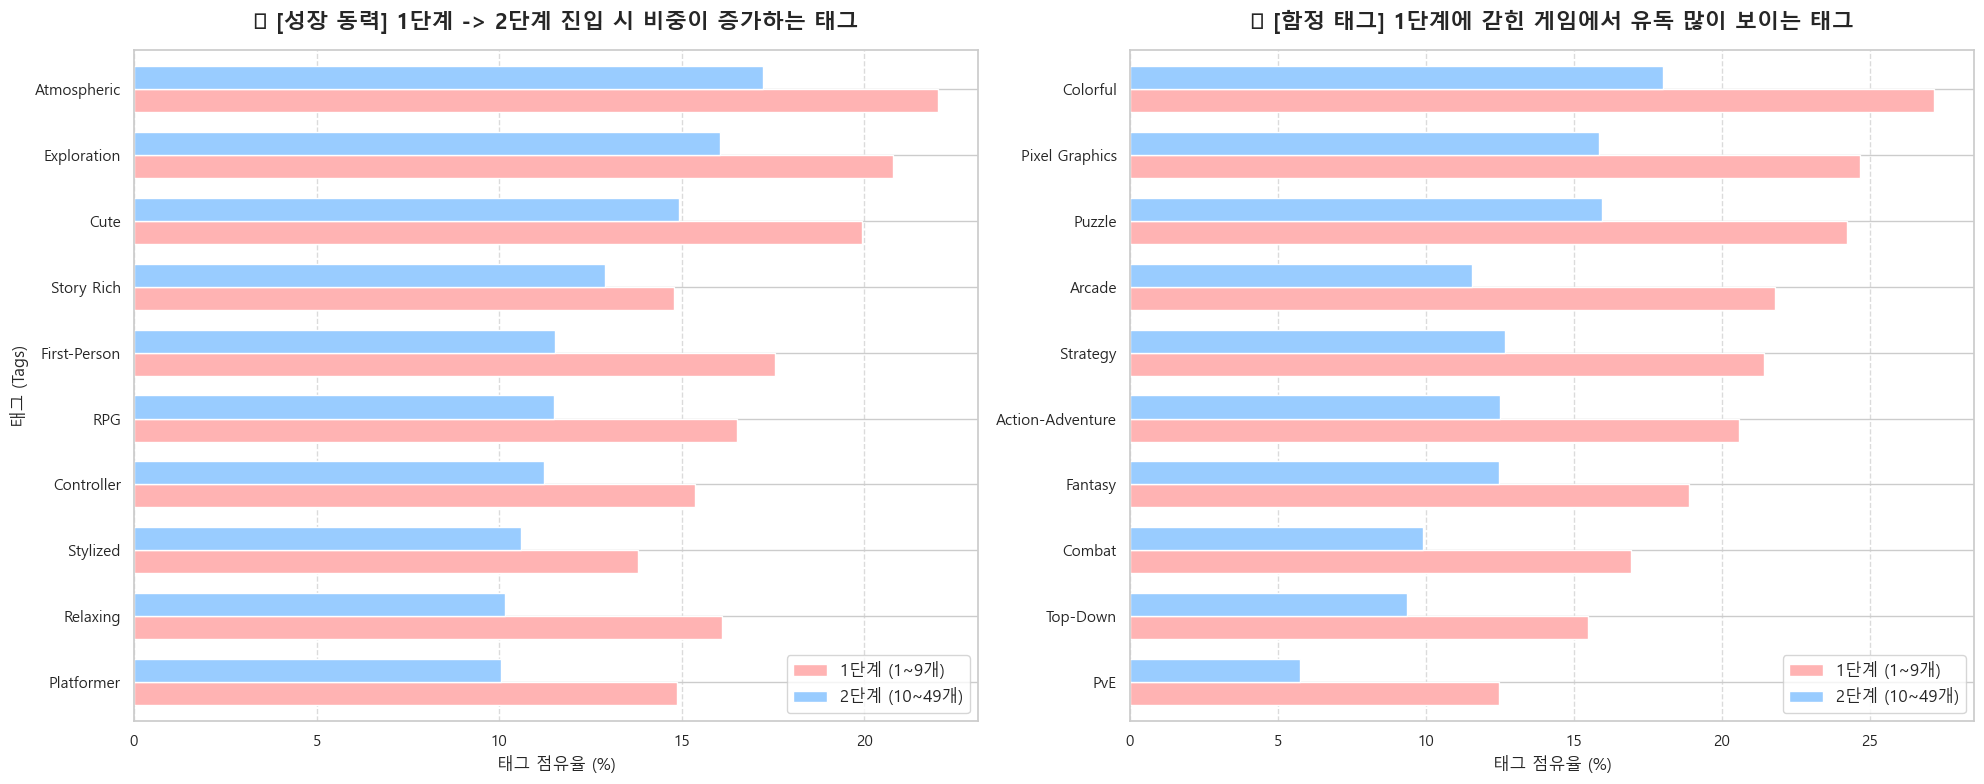

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ==========================================
# [5단계] 시각화: G1 vs G2 태그 변화율 바 그래프
# ==========================================
print("\n그래프를 그리는 중입니다...")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. 💡 성장 동력 태그 시각화 (G2 비중이 높은 순으로 정렬)
rising_plot_data = rising_top10[['G1_시동 (1~9개)', 'G2_생존 (10~49개)']].sort_values(by='G2_생존 (10~49개)', ascending=True)
rising_plot_data.plot(kind='barh', ax=axes[0], color=['#FFB3B3', '#99CCFF'], width=0.7)

axes[0].set_title("💡 [성장 동력] 1단계 -> 2단계 진입 시 비중이 증가하는 태그", fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel("태그 점유율 (%)", fontsize=12)
axes[0].set_ylabel("태그 (Tags)", fontsize=12)
axes[0].legend(['1단계 (1~9개)', '2단계 (10~49개)'], fontsize=12, loc='lower right')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# 2. 💀 정체(함정) 태그 시각화 (G1 비중이 높은 순으로 정렬)
trap_plot_data = trap_top10[['G1_시동 (1~9개)', 'G2_생존 (10~49개)']].sort_values(by='G1_시동 (1~9개)', ascending=True)
trap_plot_data.plot(kind='barh', ax=axes[1], color=['#FFB3B3', '#99CCFF'], width=0.7)

axes[1].set_title("💀 [함정 태그] 1단계에 갇힌 게임에서 유독 많이 보이는 태그", fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel("태그 점유율 (%)", fontsize=12)
axes[1].set_ylabel("") # 왼쪽 그래프와 겹치므로 생략
axes[1].legend(['1단계 (1~9개)', '2단계 (10~49개)'], fontsize=12, loc='lower right')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


그래프를 그리는 중입니다...


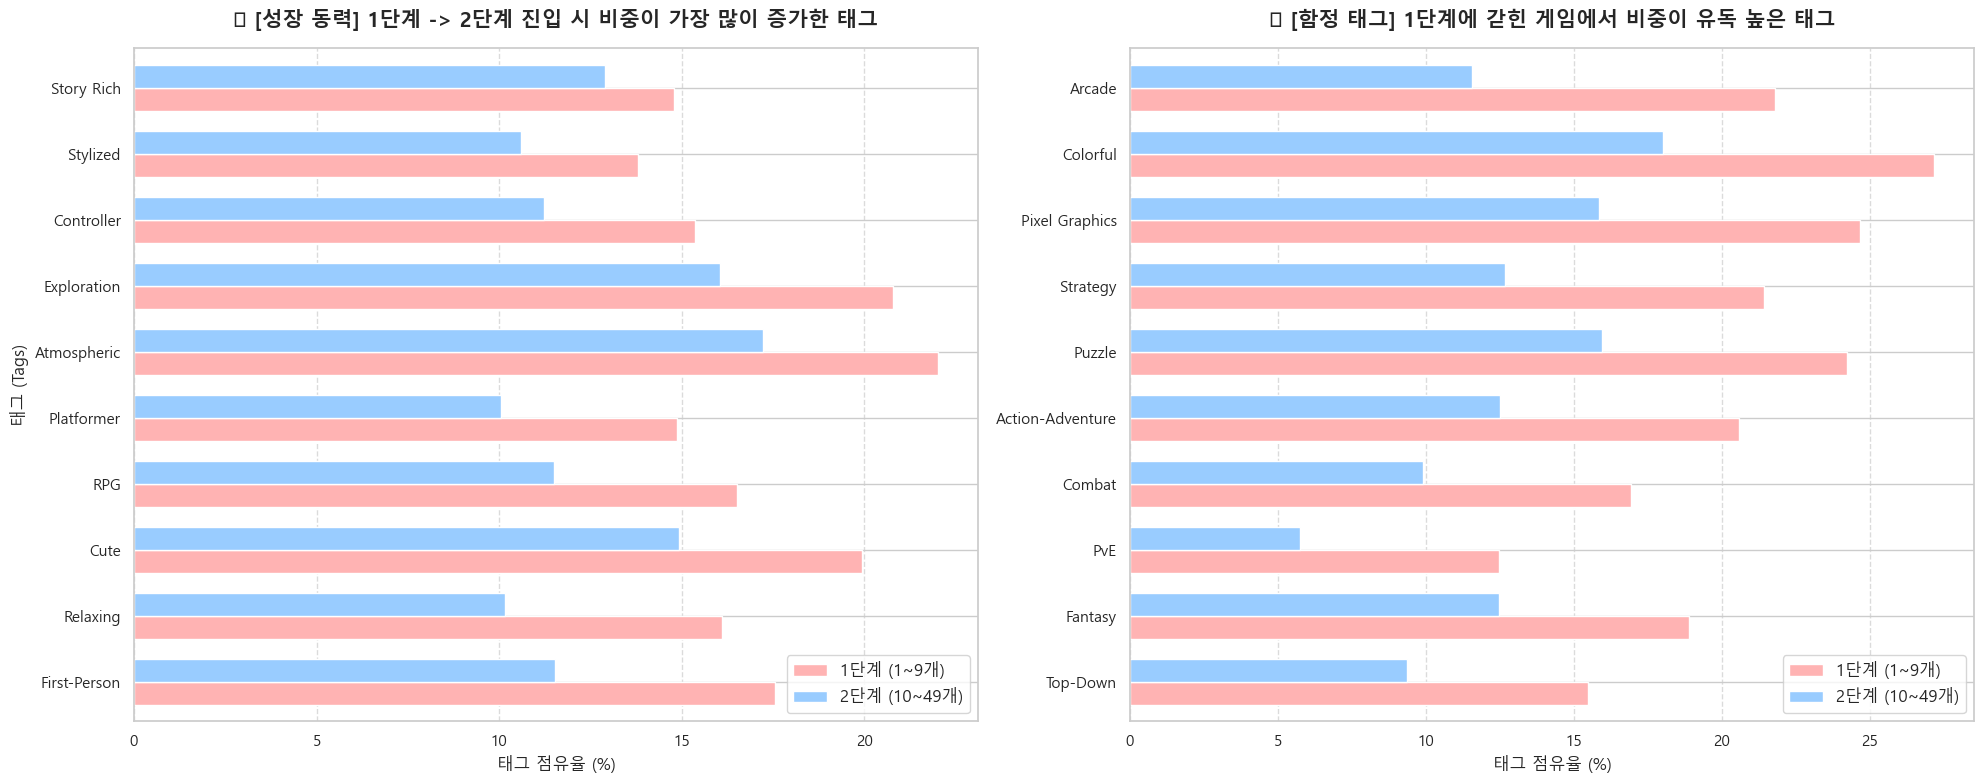

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ==========================================
# ==========================================
# [5단계] 시각화: G1 vs G2 태그 변화율 바 그래프 (수정본)
# ==========================================
print("\n그래프를 그리는 중입니다...")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. 💡 성장 동력 태그 시각화 (디스플레이와 동일하게 '성장폭' 기준으로 정렬)
# iloc[::-1] 을 써서 표의 순서를 뒤집어 넣어주면, 바 그래프에서는 위에서부터 1등이 나옵니다.
rising_plot_data = rising_top10[['G1_시동 (1~9개)', 'G2_생존 (10~49개)']].iloc[::-1]
rising_plot_data.plot(kind='barh', ax=axes[0], color=['#FFB3B3', '#99CCFF'], width=0.7)

axes[0].set_title("💡 [성장 동력] 1단계 -> 2단계 진입 시 비중이 가장 많이 증가한 태그", fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel("태그 점유율 (%)", fontsize=12)
axes[0].set_ylabel("태그 (Tags)", fontsize=12)
axes[0].legend(['1단계 (1~9개)', '2단계 (10~49개)'], fontsize=12, loc='lower right')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# 2. 💀 정체(함정) 태그 시각화 (디스플레이와 동일하게 '성장폭' 기준으로 정렬)
trap_plot_data = trap_top10[['G1_시동 (1~9개)', 'G2_생존 (10~49개)']].iloc[::-1]
trap_plot_data.plot(kind='barh', ax=axes[1], color=['#FFB3B3', '#99CCFF'], width=0.7)

axes[1].set_title("💀 [함정 태그] 1단계에 갇힌 게임에서 비중이 유독 높은 태그", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("태그 점유율 (%)", fontsize=12)
axes[1].set_ylabel("") # 왼쪽 그래프와 겹치므로 생략
axes[1].legend(['1단계 (1~9개)', '2단계 (10~49개)'], fontsize=12, loc='lower right')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
axes[1].legend(['1단계 (1~9개)', '2단계 (10~49개)'], fontsize=12, loc='lower right')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# (1. 데이터 로드 및 stage 할당은 기존과 동일하게 진행)

# 2. 태그 리스트 추출 함수
def extract_tags(tag_str):
    if pd.isna(tag_str):
        return []
    try:
        tag_dict = json.loads(tag_str.replace('""', '"'))
        return list(tag_dict.keys())
    except:
        return []

df['tag_list'] = df['tags'].apply(extract_tags)

# 3. 🚨 [핵심] 분모를 '게임 수'가 아닌 '전체 태그 수'로 변경하여 점유율(%) 계산
def get_tag_market_share(stage_num):
    # 해당 단계의 모든 태그를 하나의 거대한 리스트로 펼침
    all_tags = [tag for sublist in df[df['stage'] == stage_num]['tag_list'] for tag in sublist]
    total_tags = len(all_tags)
    tag_counts = Counter(all_tags)
    # 각 태그의 '시장 점유율(Market Share)' 계산
    return {k: (v / total_tags) * 100 for k, v in tag_counts.items()}

ratio_s1 = get_tag_market_share(1)
ratio_s2 = get_tag_market_share(2)

# 4. 비교 데이터프레임 생성
comparison = []
for tag in set(list(ratio_s1.keys()) + list(ratio_s2.keys())):
    r1 = ratio_s1.get(tag, 0)
    r2 = ratio_s2.get(tag, 0)
    comparison.append({
        'Tag': tag,
        'Stage1_Share(%)': r1,
        'Stage2_Share(%)': r2,
        'Growth(%p)': r2 - r1  # 성장폭
    })

comp_df = pd.DataFrame(comparison)

# 노이즈 제거: 2단계에서 점유율이 최소 0.5% 이상인 의미 있는 태그만 필터링
comp_df = comp_df[comp_df['Stage2_Share(%)'] >= 0.5]

# 5. Top 10 추출
rising_top10 = comp_df.sort_values('Growth(%p)', ascending=False).head(10)
trap_top10 = comp_df.sort_values('Growth(%p)', ascending=True).head(10)

print("💡 [성장 동력] 1단계 -> 2단계 진입 시 '시장 점유율'이 폭증하는 태그")
display(rising_top10.round(3))

print("\n💀 [함정 태그] 2단계로 가면서 거품이 쫙 빠지는(점유율 급락) 태그")
display(trap_top10.round(3))

💡 [성장 동력] 1단계 -> 2단계 진입 시 '시장 점유율'이 폭증하는 태그


,Tag,Stage1_Share(%),Stage2_Share(%),Growth(%p)
365,Psychological Horror,0.522,0.914,0.392
401,Horror,0.832,1.170,0.338
353,Atmospheric,1.317,1.632,0.315
262,Story Rich,0.884,1.178,0.294
73,Walking Simulator,0.296,0.589,0.293
215,First-Person,1.050,1.320,0.270
8,Exploration,1.244,1.496,0.252
192,Simulation,1.064,1.270,0.205
172,Cute,1.193,1.394,0.201
258,Adventure,2.452,2.632,0.180



💀 [함정 태그] 2단계로 가면서 거품이 쫙 빠지는(점유율 급락) 태그


,Tag,Stage1_Share(%),Stage2_Share(%),Growth(%p)
89,Casual,3.124,2.609,-0.515
182,Indie,4.105,3.599,-0.506
91,Singleplayer,4.743,4.338,-0.405
318,2D,2.774,2.392,-0.382
195,Arcade,1.302,0.942,-0.360
235,Action,2.714,2.416,-0.298
223,PvE,0.747,0.504,-0.243
140,Strategy,1.279,1.038,-0.241
42,Combat,1.011,0.776,-0.236
105,Shooter,0.825,0.602,-0.223


In [24]:
import pandas as pd
import numpy as np
import json
from collections import Counter
from scipy.stats import chi2_contingency

# (1. 데이터 로드 및 stage 할당, tag_list 추출은 동일하게 진행)

# 2. 🚨 [추가됨] 점유율뿐만 아니라 통계 검증을 위한 '실제 카운트(Count)' 추출
def get_tag_counts(stage_num):
    all_tags = [tag for sublist in df[df['stage'] == stage_num]['tag_list'] for tag in sublist]
    total_tags = len(all_tags)
    tag_counts = Counter(all_tags)
    return tag_counts, total_tags

count_s1, total_s1 = get_tag_counts(1)
count_s2, total_s2 = get_tag_counts(2)

# 3. 비교 데이터프레임 및 통계 검증(카이제곱 검정) 수행
comparison = []
all_unique_tags = set(list(count_s1.keys()) + list(count_s2.keys()))

for tag in all_unique_tags:
    c1 = count_s1.get(tag, 0)
    c2 = count_s2.get(tag, 0)
    
    # 시장 점유율(%)
    r1 = (c1 / total_s1) * 100 if total_s1 > 0 else 0
    r2 = (c2 / total_s2) * 100 if total_s2 > 0 else 0
    
    # 2x2 교차표 생성: [해당 태그 카운트, 나머지 태그 카운트]
    rest1 = total_s1 - c1
    rest2 = total_s2 - c2
    table = [[c1, rest1], [c2, rest2]]
    
    # 카이제곱 검정 및 P-value 추출
    try:
        chi2, p, _, _ = chi2_contingency(table)
    except ValueError:
        p = np.nan # 계산 불가 시 NaN
        
    # 오즈비 (Odds Ratio): 2단계에서 이 태그가 쓰일 확률이 1단계 대비 몇 배인가?
    try:
        odds_ratio = (c2 * rest1) / (c1 * rest2) if c1 > 0 else np.nan
    except ZeroDivisionError:
        odds_ratio = np.nan

    # P-value 포맷팅 (0.001보다 작으면 < 0.001로 표기)
    p_str = "< 0.001" if pd.notna(p) and p < 0.001 else f"{p:.4f}"

    comparison.append({
        'Tag': tag,
        'Stage1_Share(%)': r1,
        'Stage2_Share(%)': r2,
        'Growth(%p)': r2 - r1,
        'Odds_Ratio(배)': odds_ratio,
        'P-value': p_str,
        'Significant': '✅' if pd.notna(p) and p < 0.05 else '❌'
    })

comp_df = pd.DataFrame(comparison)

# 노이즈 제거: 2단계에서 점유율이 0.5% 이상인 의미 있는 태그만 필터링
comp_df = comp_df[comp_df['Stage2_Share(%)'] >= 0.5]

# 4. Top 10 추출 및 출력
rising_top10 = comp_df.sort_values('Growth(%p)', ascending=False).head(10)
trap_top10 = comp_df.sort_values('Growth(%p)', ascending=True).head(10)

print("💡 [성장 동력] 1단계 -> 2단계 진입 시 '시장 점유율'이 폭증하는 태그 (통계 검증 완료)")
display(rising_top10[['Tag', 'Stage1_Share(%)', 'Stage2_Share(%)', 'Growth(%p)', 'Odds_Ratio(배)', 'P-value', 'Significant']].round(3))

print("\n💀 [함정 태그] 2단계로 가면서 거품이 쫙 빠지는 태그 (통계 검증 완료)")
display(trap_top10[['Tag', 'Stage1_Share(%)', 'Stage2_Share(%)', 'Growth(%p)', 'Odds_Ratio(배)', 'P-value', 'Significant']].round(3))

💡 [성장 동력] 1단계 -> 2단계 진입 시 '시장 점유율'이 폭증하는 태그 (통계 검증 완료)


,Tag,Stage1_Share(%),Stage2_Share(%),Growth(%p),Odds_Ratio(배),P-value,Significant
365,Psychological Horror,0.522,0.914,0.392,1.758,< 0.001,✅
401,Horror,0.832,1.170,0.338,1.411,< 0.001,✅
353,Atmospheric,1.317,1.632,0.315,1.243,< 0.001,✅
262,Story Rich,0.884,1.178,0.294,1.337,< 0.001,✅
73,Walking Simulator,0.296,0.589,0.293,1.997,< 0.001,✅
215,First-Person,1.050,1.320,0.270,1.261,< 0.001,✅
8,Exploration,1.244,1.496,0.252,1.205,< 0.001,✅
192,Simulation,1.064,1.270,0.205,1.195,< 0.001,✅
172,Cute,1.193,1.394,0.201,1.171,< 0.001,✅
258,Adventure,2.452,2.632,0.180,1.076,0.0103,✅



💀 [함정 태그] 2단계로 가면서 거품이 쫙 빠지는 태그 (통계 검증 완료)


,Tag,Stage1_Share(%),Stage2_Share(%),Growth(%p),Odds_Ratio(배),P-value,Significant
89,Casual,3.124,2.609,-0.515,0.831,< 0.001,✅
182,Indie,4.105,3.599,-0.506,0.872,< 0.001,✅
91,Singleplayer,4.743,4.338,-0.405,0.911,< 0.001,✅
318,2D,2.774,2.392,-0.382,0.859,< 0.001,✅
195,Arcade,1.302,0.942,-0.360,0.721,< 0.001,✅
235,Action,2.714,2.416,-0.298,0.887,< 0.001,✅
223,PvE,0.747,0.504,-0.243,0.673,< 0.001,✅
140,Strategy,1.279,1.038,-0.241,0.810,< 0.001,✅
42,Combat,1.011,0.776,-0.236,0.765,< 0.001,✅
105,Shooter,0.825,0.602,-0.223,0.728,< 0.001,✅
